<a href="https://colab.research.google.com/github/marianapiteirarendeiro-sudo/Projects_/blob/main/Projeto_tese_EN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')
folder = "/content/drive/MyDrive/Projeto_tese"
import os
os.listdir(folder)

Mounted at /content/drive


['PORDATA_Índice-de-envelhecimento (12).xlsx',
 'PORDATA_NUTS2013_Densidade-populacional (5).xlsx',
 'IUTICF2024_QuadrosAnexo_PT_retif20241122.xlsx',
 'consultas-em-telemedicina (4).csv',
 'consultas-em-telemedicina (5).xlsx',
 'QuadroSíntese2012-2023_PT.xlsx',
 'pordata (3).xlsx',
 'PORDATA_NUTS2013_Por-grandes-grupos-etários.xlsx',
 'Projeto_tese_corrigido (7).ipynb',
 'Projeto_tese_corrigido (6).ipynb',
 'Projeto_tese_corrigido (5).ipynb',
 'Projeto_tese_corrigido (4).ipynb',
 'Projeto_tese_corrigido (3).ipynb',
 'Projeto_tese_corrigido (2).ipynb',
 'Projeto_tese_corrigido (1).ipynb',
 'teleconsultas-atraves-da-plataforma-live.csv',
 'Projeto_tese_corrigido.ipynb',
 '01_sica_evolucao-mensal-das-consultas-medicas-hospitalares.csv',
 'hlth_hc_phys2$defaultview_spreadsheet (1).xlsx',
 'Projeto_tese_EN.ipynb']

In [2]:
# Regioes de Portugal Continental
REGIOES = ["Norte", "Centro", "LVT", "Alentejo", "Algarve"]


In [3]:
import pandas as pd

tele = pd.read_csv(
    folder + "/consultas-em-telemedicina (4).csv",
    sep=";"
)

tele.head()

,Período,Região,Instituição,Localização Geográfica,1as Consultas Telemedicina,Consultas Subsequentes Telemedicina,Total Consultas Telemedicina
0,2024-01,Região de Saúde LVT,"Hospital de Cascais, PPP","38.730076, -9.418207",NaN,NaN,NaN
1,2024-01,Região de Saúde do Centro,"Unidade Local de Saúde Castelo Branco, EPE","39.822737, -7.499876",253.0,591.0,844.0
2,2024-01,Região de Saúde LVT,"Unidade Local de Saúde da Lezíria, EPE","39.232503, -8.715083",2.0,248.0,250.0
3,2024-01,Região de Saúde LVT,"Unidade Local de Saúde de Amadora/Sintra, EPE","38.7436332060551, -9.0",297.0,2307.0,2604.0
4,2024-01,Região de Saúde LVT,"Unidade Local de Saúde de Loures-Odivelas, EPE","38.821769, -9.176301",NaN,NaN,NaN


In [4]:
tele.columns = [
    "periodo",
    "regiao",
    "instituicao",
    "geo",
    "primeiras",
    "subsequentes",
    "total"
]
tele["total"] = pd.to_numeric(tele["total"], errors="coerce")
tele["primeiras"] = pd.to_numeric(tele["primeiras"], errors="coerce")
tele["subsequentes"] = pd.to_numeric(tele["subsequentes"], errors="coerce")

In [5]:
tele["ano"] = tele["periodo"].str[:4]

In [6]:
tele_regiao = tele.groupby(["regiao", "ano"], as_index=False)["total"].sum()

In [7]:
tele_regiao.head()

,regiao,ano,total
0,Região de Saúde LVT,2013,0.0
1,Região de Saúde LVT,2014,117.0
2,Região de Saúde LVT,2015,0.0
3,Região de Saúde LVT,2016,682.0
4,Região de Saúde LVT,2017,1780.0


In [8]:
tele_regiao["regiao"] = tele_regiao["regiao"].str.replace("Região de Saúde ", "")
tele_regiao["regiao"] = tele_regiao["regiao"].str.replace("do ", "")
tele_regiao = tele_regiao[tele_regiao["regiao"].isin(REGIOES)]


In [9]:
tele_regiao["regiao"].unique()

array(['LVT', 'Norte', 'Alentejo', 'Algarve', 'Centro'], dtype=object)

In [10]:
aging = pd.read_excel(
    folder + "/PORDATA_Índice-de-envelhecimento (12).xlsx",
    sheet_name="Quadro",
    skiprows=11
)

aging.head()

,Âmbito Geográfico,Anos,2000,2013,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 246,Unnamed: 247,Unnamed: 248,Unnamed: 249,Unnamed: 250,Unnamed: 251,Unnamed: 252,Unnamed: 253,Unnamed: 254,Unnamed: 255
0,NUTS 2024,Portugal,100.6,136.4,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NUTS I,Continente,102.8,139.1,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NUTS II,Norte,78.1,125.9,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NUTS III,Alto Minho,129.7,184.3,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Município,Arcos de Valdevez,203.6,277.7,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
aging = aging.loc[:, ~aging.columns.astype(str).str.contains("Unnamed")]

In [12]:
aging = aging.rename(columns={
    "Âmbito Geográfico": "geo",
    "Anos": "regiao"
})

aging = aging[aging["geo"] == "NUTS II"]

aging_long = aging.melt(
    id_vars=["geo", "regiao"],
    var_name="ano",
    value_name="indice_envelhecimento"
)

aging_long = aging_long.dropna()
aging_long["ano"] = aging_long["ano"].astype(str)

aging_long.head()

,geo,regiao,ano,indice_envelhecimento
0,NUTS II,Norte,2000,78.1
1,NUTS II,Centro,2000,128.1
2,NUTS II,Oeste e Vale do Tejo,2000,130.2
3,NUTS II,Grande Lisboa,2000,105.6
4,NUTS II,Península de Setúbal,2000,92.4


In [13]:
mapping = {
    "Norte": "Norte",
    "Centro": "Centro",
    "Alentejo": "Alentejo",
    "Algarve": "Algarve",
    "Grande Lisboa": "LVT",
    "Península de Setúbal": "LVT",
    "Oeste e Vale do Tejo": "LVT"
}

aging_long["regiao"] = aging_long["regiao"].map(mapping)
aging_long = aging_long[aging_long["regiao"].isin(REGIOES)]


In [14]:
aging_sns = aging_long.groupby(["regiao", "ano"], as_index=False)["indice_envelhecimento"].mean()

In [15]:
aging_sns.head()

,regiao,ano,indice_envelhecimento
0,Alentejo,2000,170.4
1,Alentejo,2013,197.7
2,Algarve,2000,126.7
3,Algarve,2013,131.4
4,Centro,2000,128.1


In [16]:
aging_final = aging_sns[aging_sns["ano"] == "2013"].copy()

In [17]:
aging_final.head()
aging_final["regiao"].unique()

array(['Alentejo', 'Algarve', 'Centro', 'LVT', 'Norte'], dtype=object)

In [18]:
df = tele_regiao.merge(aging_final, on="regiao", how="left")

In [19]:
df.head()
df.isna().sum()

,0
regiao,0
ano_x,0
total,0
ano_y,0
indice_envelhecimento,0


df_reg:
      regiao indice_envelhecimento          total
0  Alentejo                 197.7   23072.571429
1   Algarve                 131.4    4293.928571
2    Centro                 179.0  217785.428571
3       LVT                 134.5  291002.285714
4     Norte                 125.9   90661.071429
shape: (5, 3)


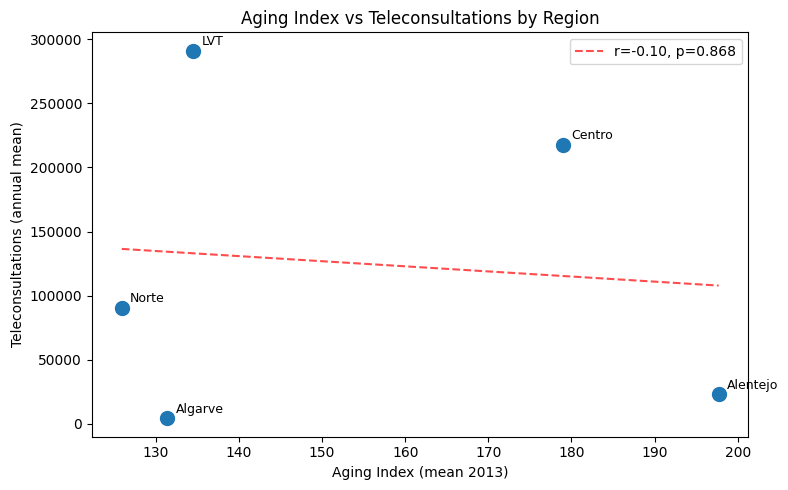

Pearson r = -0.104  |  p-value = 0.868


In [20]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress

df_reg = df.groupby("regiao")[["indice_envelhecimento", "total"]].mean().reset_index().dropna()
print("df_reg:\n", df_reg)
print("shape:", df_reg.shape)

x = df_reg["indice_envelhecimento"].values.astype(float)
y = df_reg["total"].values.astype(float)

slope, intercept, r, p, se = linregress(x, y)
x_line = np.linspace(x.min(), x.max(), 100)

plt.figure(figsize=(8, 5))
plt.scatter(x, y, s=100, zorder=5)
for _, row in df_reg.iterrows():
    plt.annotate(row["regiao"], (row["indice_envelhecimento"], row["total"]),
                 textcoords="offset points", xytext=(6, 4), fontsize=9)
plt.plot(x_line, slope * x_line + intercept, "r--", alpha=0.7,
         label=f"r={r:.2f}, p={p:.3f}")
plt.xlabel("Aging Index (mean 2013)")
plt.ylabel("Teleconsultations (annual mean)")
plt.title("Aging Index vs Teleconsultations by Region")
plt.legend()
plt.tight_layout()
plt.show()
print(f"Pearson r = {r:.3f}  |  p-value = {p:.3f}")


In [21]:
df.groupby("regiao")[["total", "indice_envelhecimento"]].mean().sort_values("total", ascending=False)

,total,indice_envelhecimento
regiao,,
LVT,291002.285714,134.5
Centro,217785.428571,179.0
Norte,90661.071429,125.9
Alentejo,23072.571429,197.7
Algarve,4293.928571,131.4


In [22]:
tele_por_regiao = df.groupby("regiao", as_index=False)["total"].sum()
tele_por_regiao = tele_por_regiao.sort_values("total", ascending=False)

tele_por_regiao

,regiao,total
3,LVT,4074032.0
2,Centro,3048996.0
4,Norte,1269255.0
0,Alentejo,323016.0
1,Algarve,60115.0


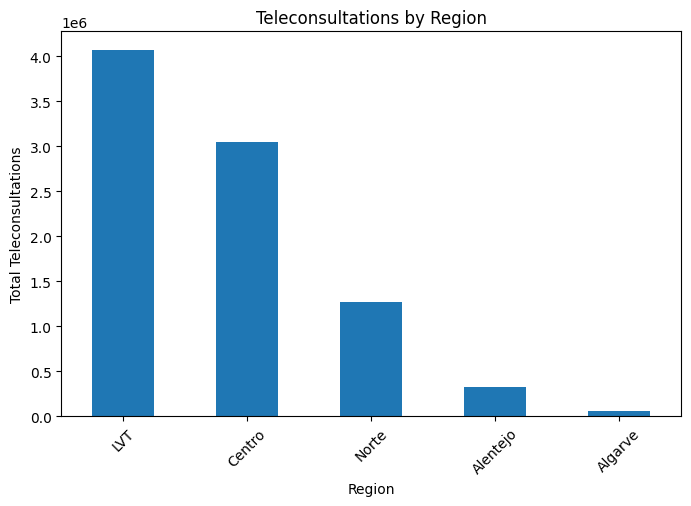

In [23]:
import matplotlib.pyplot as plt

tele_por_regiao.plot(
    x="regiao",
    y="total",
    kind="bar",
    legend=False,
    figsize=(8,5)
)

plt.xlabel("Region")
plt.ylabel("Total Teleconsultations")
plt.title("Teleconsultations by Region")
plt.xticks(rotation=45)
plt.show()

In [24]:
digital = pd.read_excel(
    folder + "/IUTICF2024_QuadrosAnexo_PT_retif20241122.xlsx",
    header=None
)

digital.head(15)

,0
0,Retificação em 22/11/2024 no quadro 5.
1,NaN
2,Inquérito à Utilização de TIC pelas Famílias 2024
3,Índice de quadros anexos ao destaque
4,Quadro 1: Proporção de indivíduos dos 16 aos 7...
5,Quadro 2: Proporção de indivíduos dos 16 aos 7...
6,Quadro 3: Proporção de indivíduos dos 16 aos 7...
7,Quadro 4: Proporção de indivíduos dos 16 aos 7...
8,Quadro 5: Proporção de indivíduos dos 16 aos 7...
9,Quadro 6: Proporção de indivíduos dos 16 aos 7...


In [25]:
pd.read_excel(folder + "/IUTICF2024_QuadrosAnexo_PT_retif20241122.xlsx", sheet_name=None).keys()

dict_keys(['Indice', 'Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6', 'Q7', 'Q8', 'Q9', 'Q10', 'Q11', 'Q12', 'Q13', 'Q14', 'Q15', 'Q16', 'Q17', 'Q18', 'Q19', 'Q20', 'Q21', 'Q22', 'Q23', 'Q24', 'Q25', 'Q26', 'Q27', 'Q28', 'Q29', 'Q30', 'Q31', 'Q32', 'Q33', 'Q34', 'Q35', 'Q36', 'Q37', 'Q38', 'Q39', 'Q40', 'Q41', 'Q42', 'Q43', 'Q44', 'Q45', 'Q46', 'Q47', 'Q48', 'Q49', 'Q50', 'Q51'])

In [26]:
q3 = pd.read_excel(
    folder + "/IUTICF2024_QuadrosAnexo_PT_retif20241122.xlsx",
    sheet_name="Q3",
    skiprows=4
)

q3.head()

,Continente,88.5,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,Norte,85.6,NaN,NaN,NaN
1,Centro,86.1,NaN,NaN,NaN
2,Oeste e Vale do Tejo,85.9,NaN,NaN,NaN
3,Grande Lisboa,94.1,NaN,NaN,NaN
4,Península de Setúbal,95.3,NaN,NaN,NaN


In [27]:
q3 = q3.iloc[:, :2].copy()

q3.columns = ["regiao", "internet_usage"]

q3["regiao"] = q3["regiao"].replace({
    "Grande Lisboa": "LVT",
    "Península de Setúbal": "LVT",
    "Oeste e Vale do Tejo": "LVT"
})

q3 = q3.groupby("regiao", as_index=False)["internet_usage"].mean()

q3

,regiao,internet_usage
0,Alentejo,85.400000
1,Algarve,91.500000
2,Centro,86.100000
3,"Fonte: INE, Inquérito à Utilização de Tecnolog...",NaN
4,LVT,91.766667
5,Norte,85.600000
6,Notas:\nUniverso: Indivíduos com idade entre 1...,NaN
7,R. A. Açores,88.300000
8,R. A. Madeira,87.600000


In [28]:
df_digital = tele_por_regiao.merge(q3, on="regiao", how="left")

df_digital

,regiao,total,internet_usage
0,LVT,4074032.0,91.766667
1,Centro,3048996.0,86.100000
2,Norte,1269255.0,85.600000
3,Alentejo,323016.0,85.400000
4,Algarve,60115.0,91.500000


In [29]:
df_digital[["total", "internet_usage"]].corr()

,total,internet_usage
total,1.000000,0.229606
internet_usage,0.229606,1.000000


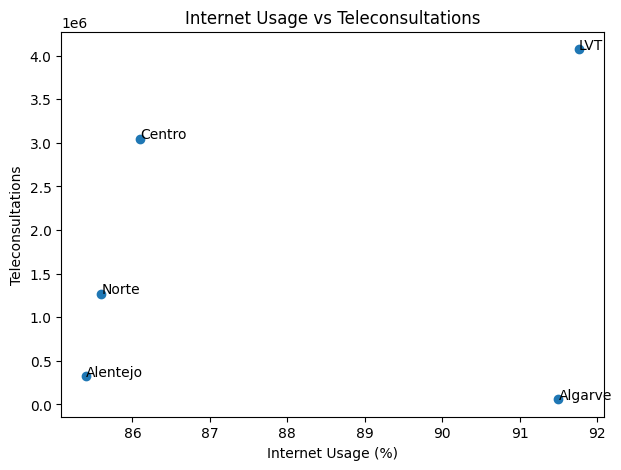

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.scatter(df_digital["internet_usage"], df_digital["total"])

for i, row in df_digital.iterrows():
    plt.text(row["internet_usage"], row["total"], row["regiao"])

plt.xlabel("Internet Usage (%)")
plt.ylabel("Teleconsultations")
plt.title("Internet Usage vs Teleconsultations")
plt.show()

In [31]:
pop_raw = pd.read_excel(
    folder + "/PORDATA_NUTS2013_Por-grandes-grupos-etários.xlsx",
    skiprows=11
)

pop_raw.head()

,Âmbito Geográfico,Anos,2001,2009,2010,2011,2012,2013,2014,2015,...,2013.3,2014.3,2015.3,2016.3,2017.3,2018.3,2019.3,2020.3,2021.3,2022.3
0,NUTS 2013,Portugal,10362722,10568247,10573100,10565836,10531420,10473991,10419607,10381838,...,2068472,2106581,2145236,2185732,2229257,2273940,2327150,2385368,2436949,2484783
1,NUTS I,Continente,9874675,10055535,10058932,10051230,10018638,9964912,9915621,9883307,...,1995007,2032227,2069591,2108295,2149726,2192142,2242713,2298123,2347121,2392718
2,NUTS II,Norte,3688037,3709267,3699783,3688728,3673378,3651843,3629804,3612299,...,651826,668675,685928,704488,724447,744610,767791,791754,814525,838112
3,NUTS III,Alto Minho,250079,247091,245998,244343,242325,240193,238008,236159,...,56139,57007,57890,58950,60173,61338,62771,64255,65358,66302
4,Município,Arcos de Valdevez,24686,23297,23046,22645,22240,21944,21664,21420,...,6733,6762,6790,6867,6992,7102,7237,7383,7456,7509


In [32]:
pop_raw.columns

Index(['Âmbito Geográfico',              'Anos',                2001,
                      2009,                2010,                2011,
                      2012,                2013,                2014,
                      2015,                2016,                2017,
                      2018,                2019,                2020,
                      2021,                2022,            '2001.1',
                  '2009.1',            '2010.1',            '2011.1',
                  '2012.1',            '2013.1',            '2014.1',
                  '2015.1',            '2016.1',            '2017.1',
                  '2018.1',            '2019.1',            '2020.1',
                  '2021.1',            '2022.1',            '2001.2',
                  '2009.2',            '2010.2',            '2011.2',
                  '2012.2',            '2013.2',            '2014.2',
                  '2015.2',            '2016.2',            '2017.2',
                  '2

In [33]:
pop = pop_raw.rename(columns={
    "Âmbito Geográfico": "geo",
    "Anos": "regiao"
})

pop = pop[pop["geo"] == "NUTS II"]

In [34]:
pop = pop[["regiao", 2013]]
pop = pop.rename(columns={2013: "populacao"})

In [35]:
pop = pop_raw.rename(columns={
    "Âmbito Geográfico": "geo",
    "Anos": "regiao"
})

pop = pop[pop["geo"] == "NUTS II"]

# ESCOLHE UM ANO
pop = pop[["regiao", 2013]]

pop = pop.rename(columns={2013: "populacao"})

In [36]:
mapping = {
    "Norte": "Norte",
    "Centro": "Centro",
    "Alentejo": "Alentejo",
    "Algarve": "Algarve",
    "Grande Lisboa": "LVT",
    "Península de Setúbal": "LVT",
    "Oeste e Vale do Tejo": "LVT"
}

pop["regiao"] = pop["regiao"].map(mapping)
pop = pop[pop["regiao"].isin(REGIOES)]

pop = pop.groupby("regiao", as_index=False)["populacao"].sum()


In [37]:
df_digital = df_digital.merge(pop, on="regiao", how="left")

df_digital["tele_per_1000"] = (df_digital["total"] / df_digital["populacao"]) * 1000

In [38]:
df_digital

,regiao,total,internet_usage,populacao,tele_per_1000
0,LVT,4074032.0,91.766667,NaN,NaN
1,Centro,3048996.0,86.100000,2300752,1325.217146
2,Norte,1269255.0,85.600000,3651843,347.565599
3,Alentejo,323016.0,85.400000,743923,434.206228
4,Algarve,60115.0,91.500000,450515,133.436179


In [39]:
df_digital.loc[df_digital["regiao"] == "LVT", "populacao"] = 3631000

df_digital["tele_per_1000"] = (df_digital["total"] / df_digital["populacao"]) * 1000

df_digital

,regiao,total,internet_usage,populacao,tele_per_1000
0,LVT,4074032.0,91.766667,3631000,1122.01377
1,Centro,3048996.0,86.100000,2300752,1325.217146
2,Norte,1269255.0,85.600000,3651843,347.565599
3,Alentejo,323016.0,85.400000,743923,434.206228
4,Algarve,60115.0,91.500000,450515,133.436179


In [40]:
df_digital[["tele_per_1000", "internet_usage"]].corr()

,tele_per_1000,internet_usage
tele_per_1000,1.000000,-0.005059
internet_usage,-0.005059,1.000000


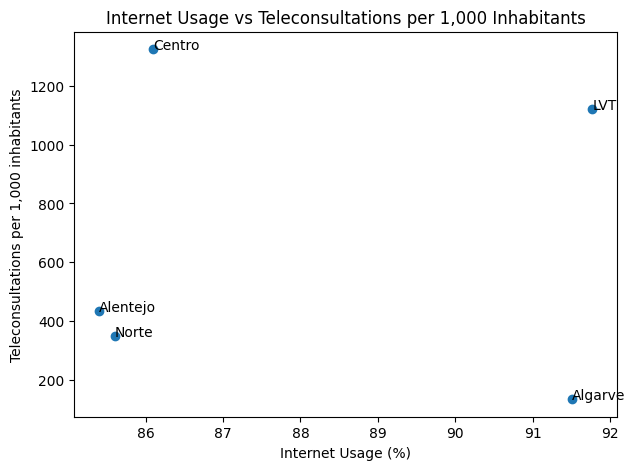

In [41]:
plt.figure(figsize=(7,5))
plt.scatter(df_digital["internet_usage"], df_digital["tele_per_1000"])

for i, row in df_digital.iterrows():
    plt.text(row["internet_usage"], row["tele_per_1000"], row["regiao"])

plt.xlabel("Internet Usage (%)")
plt.ylabel("Teleconsultations per 1,000 inhabitants")
plt.title("Internet Usage vs Teleconsultations per 1,000 Inhabitants")
plt.show()

In [42]:
# ============================================================
# ANÁLISE: Primeiras vs Subsequentes
# ============================================================
from scipy.stats import chi2_contingency

tele2 = tele.copy()
tele2["regiao"] = tele2["regiao"].str.replace("Região de Saúde ", "").str.replace("do ", "")
tele2 = tele2[tele2["regiao"].isin(REGIOES)]
tele2["ano"] = tele2["periodo"].str[:4].astype(int)
tele2["primeiras"] = pd.to_numeric(tele2["primeiras"], errors="coerce")
tele2["subsequentes"] = pd.to_numeric(tele2["subsequentes"], errors="coerce")
print("Data ready:", tele2.shape)


Data ready: (4283, 8)


## 7.5 Data Preprocessing: Missing Values, Outliers and Normalization

Before moving on to the regional and temporal analyses, we check the working dataset (`tele2`) for missing values and outliers, and prepare a normalized version of the numeric variables (`primeiras`, `subsequentes`, `total`). This preprocessing is done on a separate copy so it does not affect the totals used in the rest of the notebook.

In [43]:
import seaborn as sns

# Copy of the dataset for preprocessing demonstration
df_prep = tele2.copy()
numeric_features = ["primeiras", "subsequentes", "total"]

print("Missing values per column:")
print(df_prep[numeric_features].isna().sum())

Missing values per column:
primeiras       260
subsequentes    581
total           169
dtype: int64


In [44]:
# Fill missing values using the mean (measure of central tendency)
means = df_prep[numeric_features].mean()
df_prep[numeric_features] = df_prep[numeric_features].fillna(means)

print("Missing values after mean imputation:")
print(df_prep[numeric_features].isna().sum())

Missing values after mean imputation:
primeiras       0
subsequentes    0
total           0
dtype: int64


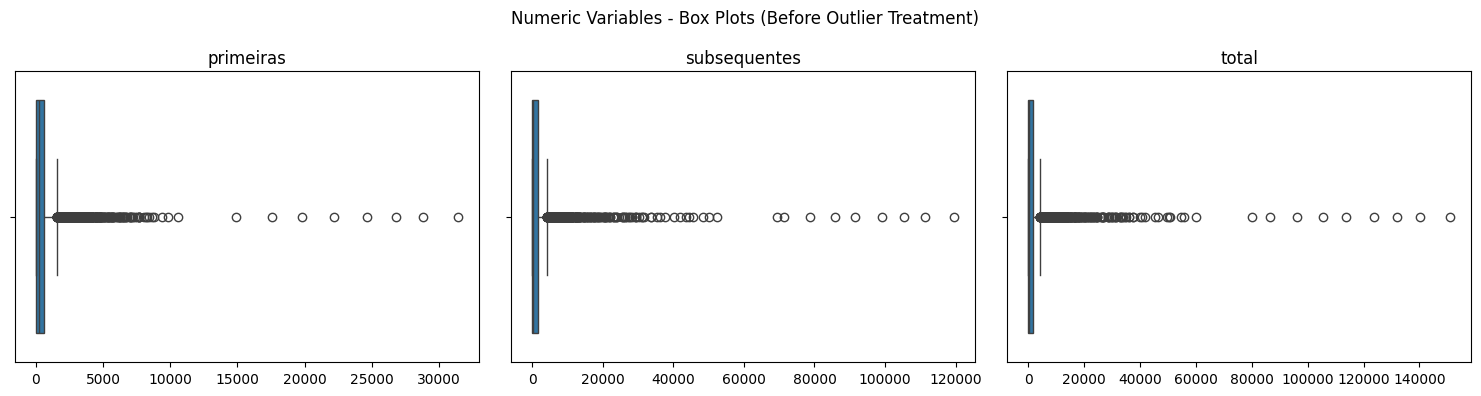

In [45]:
# Box plots before outlier treatment
fig, axes = plt.subplots(1, len(numeric_features), figsize=(15, 4))
for ax, feat in zip(axes, numeric_features):
    sns.boxplot(x=df_prep[feat], ax=ax)
    ax.set_title(feat)
    ax.set_xlabel("")
plt.suptitle("Numeric Variables - Box Plots (Before Outlier Treatment)")
plt.tight_layout()
plt.show()

**Outlier treatment using the IQR method**

Values below `Q1 - 1.5*IQR` or above `Q3 + 1.5*IQR` are capped at those limits. Note that teleconsultation volumes are strongly right-skewed (e.g. the COVID-19 surge), so some "outliers" reflect real events rather than data errors. IQR capping is useful to reduce the influence of extreme points in correlation/regression analyses, but should be used with caution (or not at all) when the goal is to study the surge itself.

In [46]:
# Outlier treatment using the IQR method (capping at the limits)
df_iqr = df_prep.copy()

for feat in numeric_features:
    q1 = df_iqr[feat].quantile(0.25)
    q3 = df_iqr[feat].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_outliers = ((df_iqr[feat] < lower) | (df_iqr[feat] > upper)).sum()
    df_iqr[feat] = df_iqr[feat].clip(lower=lower, upper=upper)
    print(f"{feat}: {n_outliers} outliers capped (limits: {lower:.1f} to {upper:.1f})")

primeiras: 443 outliers capped (limits: -865.8 to 1533.7)
subsequentes: 375 outliers capped (limits: -2497.4 to 4189.1)
total: 475 outliers capped (limits: -2507.2 to 4370.8)


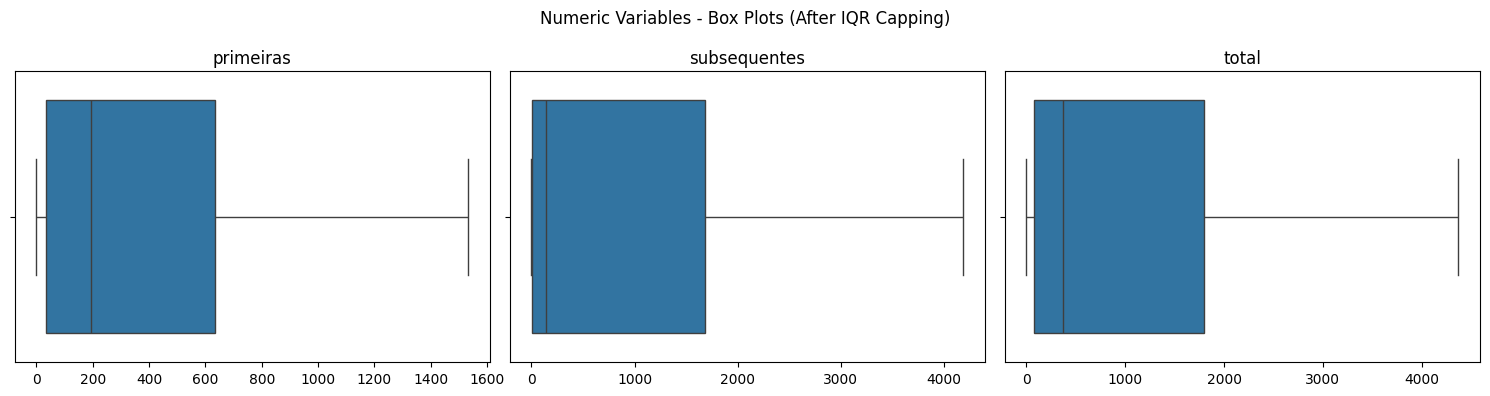

In [47]:
# Box plots after IQR capping
fig, axes = plt.subplots(1, len(numeric_features), figsize=(15, 4))
for ax, feat in zip(axes, numeric_features):
    sns.boxplot(x=df_iqr[feat], ax=ax)
    ax.set_title(feat)
    ax.set_xlabel("")
plt.suptitle("Numeric Variables - Box Plots (After IQR Capping)")
plt.tight_layout()
plt.show()

In [48]:
# Data Normalization (Min-Max scaling)
from sklearn.preprocessing import MinMaxScaler

df_norm = df_prep.copy()
scaler = MinMaxScaler()
df_norm[numeric_features] = scaler.fit_transform(df_norm[numeric_features])

df_norm[numeric_features].describe()

,primeiras,subsequentes,total
count,4283.000000,4283.000000,4283.000000
mean,0.020171,0.014067,0.014129
std,0.047213,0.048214,0.046360
min,0.000000,0.000000,0.000000
25%,0.001082,0.000084,0.000477
50%,0.006205,0.001213,0.002457
75%,0.020171,0.014067,0.011867
max,1.000000,1.000000,1.000000


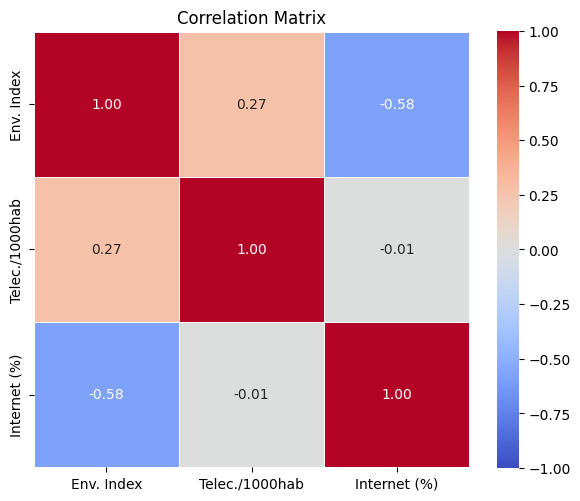

                Env. Index  Telec./1000hab  Internet (%)
Env. Index           1.000           0.273        -0.581
Telec./1000hab       0.273           1.000        -0.005
Internet (%)        -0.581          -0.005         1.000


In [49]:
# Juntar variaveis disponiveis numa tabela por regiao
df_corr = df_digital.merge(
    aging_final[["regiao", "indice_envelhecimento"]], on="regiao", how="left"
)
cols = ["indice_envelhecimento", "tele_per_1000", "internet_usage"]
labels = ["Env. Index", "Telec./1000hab", "Internet (%)"]

corr_m = df_corr[cols].corr()
corr_m.index = labels
corr_m.columns = labels

plt.figure(figsize=(6, 5))
sns.heatmap(corr_m, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5, vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()
print(corr_m.round(3))


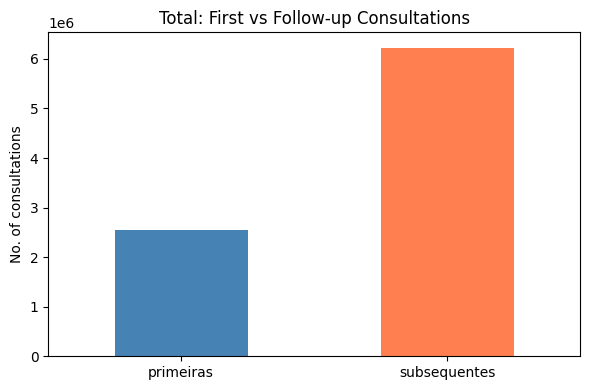

First consult.:  2,550,051
Follow-up:       6,225,363
Ratio follow-up/first: 2.44x


In [50]:
# 1. PROPORÇÃO GLOBAL
totais = tele2[["primeiras", "subsequentes"]].sum()

totais.plot(kind="bar", figsize=(6,4), color=["steelblue","coral"])
plt.title("Total: First vs Follow-up Consultations")
plt.ylabel("No. of consultations")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(f"First consult.:  {int(totais['primeiras']):,}")
print(f"Follow-up:       {int(totais['subsequentes']):,}")
print(f"Ratio follow-up/first: {totais['subsequentes']/totais['primeiras']:.2f}x")


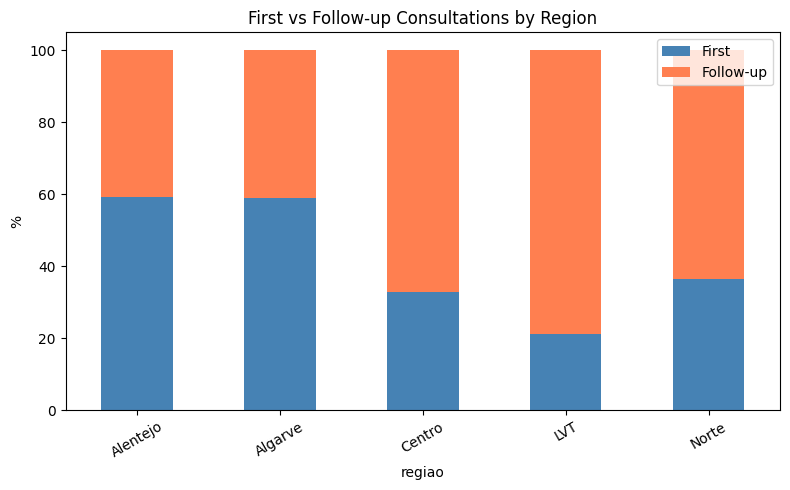

          primeiras  subsequentes
regiao                           
Alentejo       59.3          40.7
Algarve        58.9          41.1
Centro         32.9          67.1
LVT            21.1          78.9
Norte          36.5          63.5


In [51]:
# 2. PROPORÇÃO POR REGIÃO (barras empilhadas 100%)
por_regiao = tele2.groupby("regiao")[["primeiras","subsequentes"]].sum()
por_regiao_pct = por_regiao.div(por_regiao.sum(axis=1), axis=0) * 100

por_regiao_pct.plot(kind="bar", stacked=True, figsize=(8,5), color=["steelblue","coral"])
plt.title("First vs Follow-up Consultations by Region")
plt.ylabel("%")
plt.xticks(rotation=30)
plt.legend(["First","Follow-up"])
plt.tight_layout()
plt.show()

print(por_regiao_pct.round(1))


In [52]:
# 3. TESTE QUI-QUADRADO: distribuição igual entre regiões?
tabela = por_regiao[["primeiras","subsequentes"]].values
chi2, p, dof, expected = chi2_contingency(tabela)

print(f"Chi² = {chi2:.1f}")
print(f"p-value = {p:.6f}")
print(f"Degrees of freedom = {dof}")
if p < 0.05:
    print("→ Statistically significant difference between regions (p < 0.05)")
else:
    print("→ No significant difference")


Chi² = 350203.7
p-value = 0.000000
Degrees of freedom = 4
→ Statistically significant difference between regions (p < 0.05)


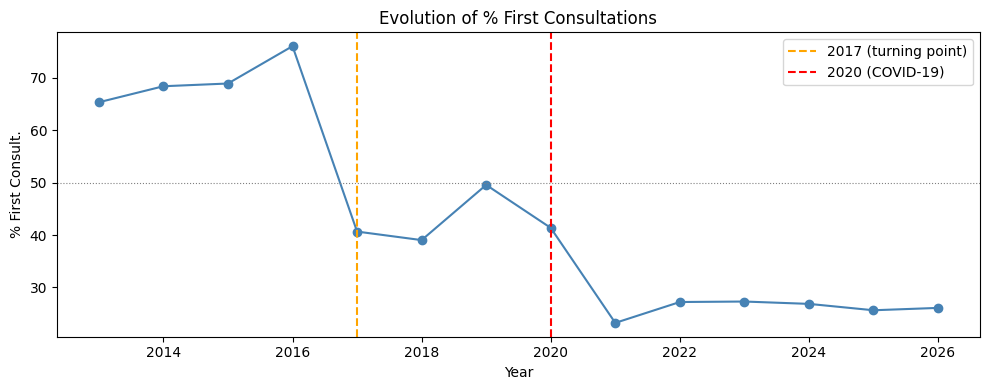

In [53]:
# 4. EVOLUÇÃO TEMPORAL: % primeiras ao longo dos anos
por_ano = tele2.groupby("ano")[["primeiras","subsequentes"]].sum()
por_ano["pct_primeiras"] = por_ano["primeiras"] / (por_ano["primeiras"] + por_ano["subsequentes"]) * 100

plt.figure(figsize=(10,4))
plt.plot(por_ano.index, por_ano["pct_primeiras"], marker="o", color="steelblue")
plt.axvline(2017, color="orange", linestyle="--", label="2017 (turning point)")
plt.axvline(2020, color="red", linestyle="--", label="2020 (COVID-19)")
plt.axhline(50, color="gray", linestyle=":", linewidth=0.8)
plt.title("Evolution of % First Consultations")
plt.ylabel("% First Consult.")
plt.xlabel("Year")
plt.legend()
plt.tight_layout()
plt.show()


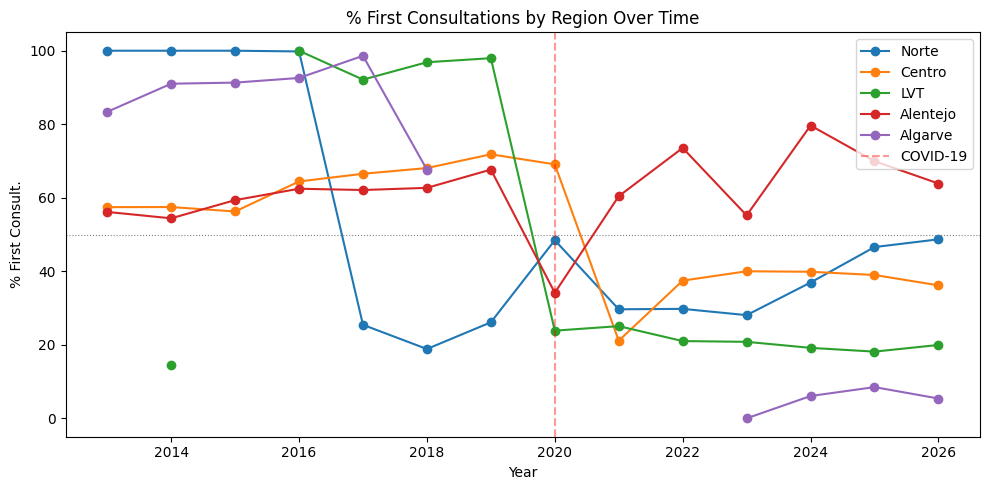

In [54]:
# 5. % PRIMEIRAS POR REGIÃO AO LONGO DO TEMPO
por_reg_ano = tele2.groupby(["regiao","ano"])[["primeiras","subsequentes"]].sum().reset_index()
por_reg_ano["pct_prim"] = (
    por_reg_ano["primeiras"] /
    (por_reg_ano["primeiras"] + por_reg_ano["subsequentes"]) * 100
)

fig, ax = plt.subplots(figsize=(10,5))
for reg in REGIOES:
    d = por_reg_ano[por_reg_ano["regiao"] == reg]
    ax.plot(d["ano"], d["pct_prim"], marker="o", label=reg)
ax.axhline(50, color="gray", linestyle=":", linewidth=0.8)
ax.axvline(2020, color="red", linestyle="--", alpha=0.4, label="COVID-19")
ax.set_title("% First Consultations by Region Over Time")
ax.set_ylabel("% First Consult.")
ax.set_xlabel("Year")
ax.legend()
plt.tight_layout()
plt.show()


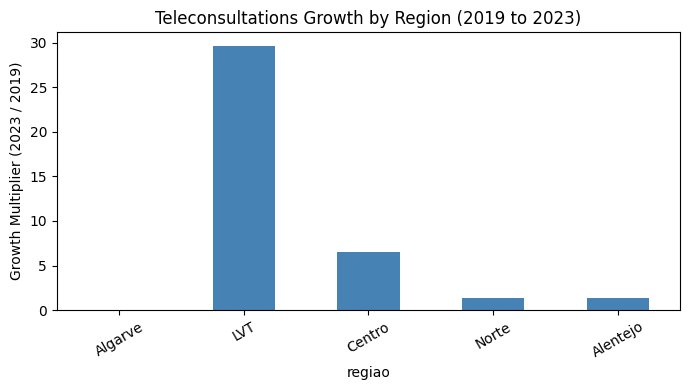

ano           2019      2023  multiplicador
regiao                                     
Algarve        0.0       2.0            inf
LVT        22817.0  677910.0           29.7
Centro     43658.0  283337.0            6.5
Norte     103590.0  144492.0            1.4
Alentejo   19437.0   25256.0            1.3


In [55]:
# 6. CRESCIMENTO POR REGIÃO: pré-COVID (2019) vs pós (2023)
cresc = (
    tele2[tele2["ano"].isin([2019, 2023])]
    .groupby(["regiao","ano"])["total"].sum()
    .unstack()
)
cresc["multiplicador"] = (cresc[2023] / cresc[2019]).round(1)

cresc["multiplicador"].sort_values(ascending=False).plot(
    kind="bar", figsize=(7,4), color="steelblue"
)
plt.title("Teleconsultations Growth by Region (2019 to 2023)")
plt.ylabel("Growth Multiplier (2023 / 2019)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print(cresc[[2019, 2023, "multiplicador"]].sort_values("multiplicador", ascending=False))


## 8. Live Platform Teleconsultations (additional dataset)

In [56]:
live = pd.read_csv(
    folder + "/teleconsultas-atraves-da-plataforma-live.csv",
    sep=";"
)

live.columns = ["periodo", "total_conferencias", "total_participantes", "total_minutos"]
live["periodo"] = pd.to_datetime(live["periodo"], format="%Y-%m")
live = live.sort_values("periodo").reset_index(drop=True)

live.head()

,periodo,total_conferencias,total_participantes,total_minutos
0,2016-10-01,15.0,22.0,53.0
1,2016-11-01,75.0,192.0,839.0
2,2016-12-01,117.0,247.0,1051.0
3,2017-01-01,83.0,170.0,1161.0
4,2017-02-01,175.0,423.0,2749.0


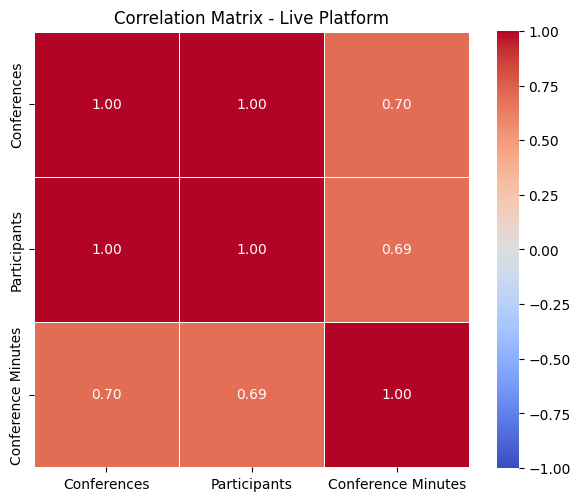

                    Conferences  Participants  Conference Minutes
Conferences               1.000         0.997               0.698
Participants              0.997         1.000               0.694
Conference Minutes        0.698         0.694               1.000


In [57]:
cols_live = ["total_conferencias", "total_participantes", "total_minutos"]
labels_live = ["Conferences", "Participants", "Conference Minutes"]

corr_live = live[cols_live].corr()
corr_live.index = labels_live
corr_live.columns = labels_live

plt.figure(figsize=(6, 5))
sns.heatmap(corr_live, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5, vmin=-1, vmax=1)
plt.title("Correlation Matrix - Live Platform")
plt.tight_layout()
plt.show()
print(corr_live.round(3))

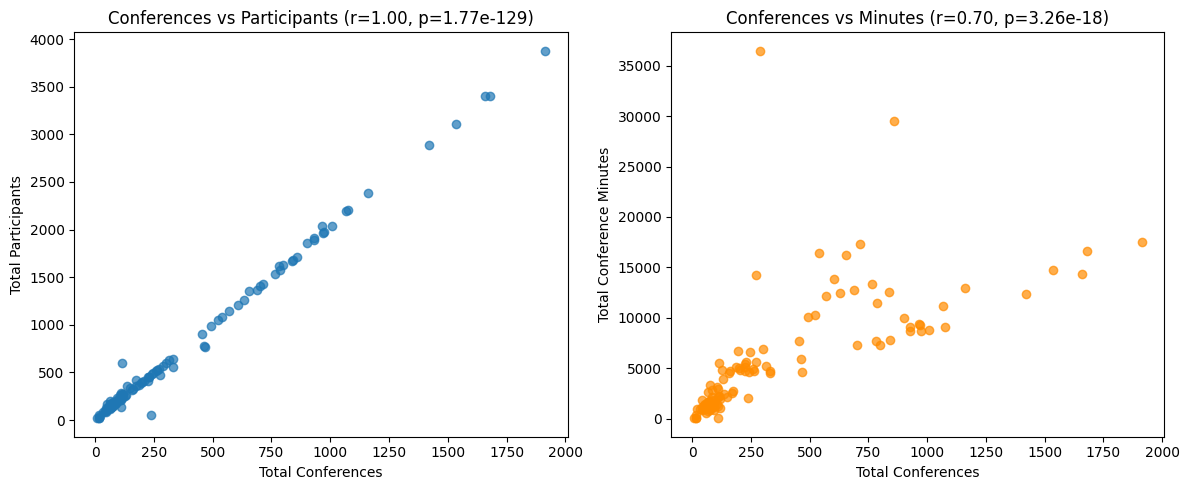

Pearson r (Conferences vs Participants) = 0.997, p-value = 1.767e-129
Pearson r (Conferences vs Minutes)      = 0.698, p-value = 3.263e-18


In [58]:
from scipy.stats import pearsonr

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(live["total_conferencias"], live["total_participantes"], alpha=0.7)
axes[0].set_xlabel("Total Conferences")
axes[0].set_ylabel("Total Participants")
r1, p1 = pearsonr(live["total_conferencias"], live["total_participantes"])
axes[0].set_title(f"Conferences vs Participants (r={r1:.2f}, p={p1:.3g})")

axes[1].scatter(live["total_conferencias"], live["total_minutos"], alpha=0.7, color="darkorange")
axes[1].set_xlabel("Total Conferences")
axes[1].set_ylabel("Total Conference Minutes")
r2, p2 = pearsonr(live["total_conferencias"], live["total_minutos"])
axes[1].set_title(f"Conferences vs Minutes (r={r2:.2f}, p={p2:.3g})")

plt.tight_layout()
plt.show()

print(f"Pearson r (Conferences vs Participants) = {r1:.3f}, p-value = {p1:.4g}")
print(f"Pearson r (Conferences vs Minutes)      = {r2:.3f}, p-value = {p2:.4g}")

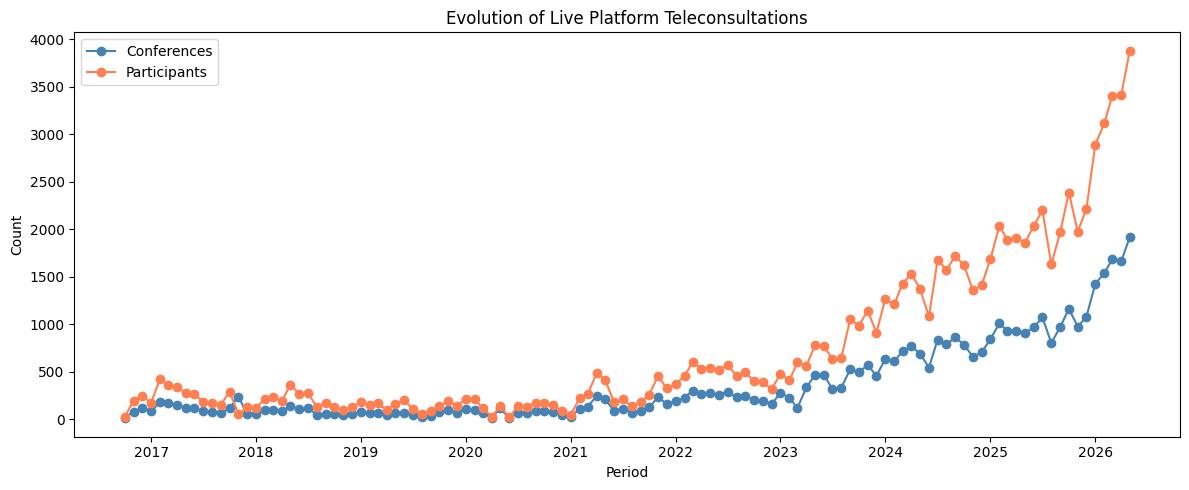

In [59]:
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(live["periodo"], live["total_conferencias"], marker="o", color="steelblue", label="Conferences")
ax1.plot(live["periodo"], live["total_participantes"], marker="o", color="coral", label="Participants")
ax1.set_xlabel("Period")
ax1.set_ylabel("Count")
ax1.set_title("Evolution of Live Platform Teleconsultations")
ax1.legend()
plt.tight_layout()
plt.show()

## 9. Modality Gap: Video (Live Platform) vs Total Teleconsultations

In [60]:
tele2["periodo_dt"] = pd.to_datetime(tele2["periodo"], format="%Y-%m")

monthly_total = tele2.groupby("periodo_dt", as_index=False)["total"].sum()
monthly_total = monthly_total.rename(columns={"total": "total_teleconsultas"})

modality = monthly_total.merge(
    live[["periodo", "total_conferencias"]].rename(
        columns={"periodo": "periodo_dt", "total_conferencias": "total_live"}
    ),
    on="periodo_dt", how="left"
)
modality["total_live"] = modality["total_live"].fillna(0)
modality["pct_video"] = (modality["total_live"] / modality["total_teleconsultas"]) * 100
modality["estimated_other"] = (modality["total_teleconsultas"] - modality["total_live"]).clip(lower=0)

modality.tail()

,periodo_dt,total_teleconsultas,total_live,pct_video,estimated_other
152,2025-09-01,174998.0,969.0,0.553721,174029.0
153,2025-10-01,198097.0,1161.0,0.586077,196936.0
154,2025-11-01,219588.0,972.0,0.442647,218616.0
155,2025-12-01,238862.0,1076.0,0.450469,237786.0
156,2026-01-01,21964.0,1422.0,6.474231,20542.0


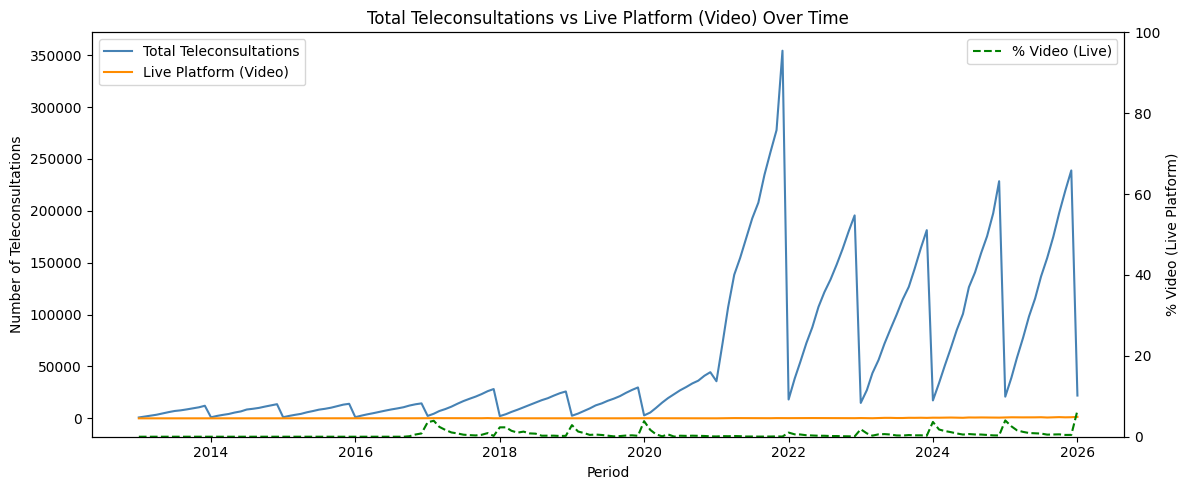

In [61]:
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(modality["periodo_dt"], modality["total_teleconsultas"], color="steelblue", label="Total Teleconsultations")
ax1.plot(modality["periodo_dt"], modality["total_live"], color="darkorange", label="Live Platform (Video)")
ax1.set_xlabel("Period")
ax1.set_ylabel("Number of Teleconsultations")
ax1.set_title("Total Teleconsultations vs Live Platform (Video) Over Time")
ax1.legend(loc="upper left")

ax2 = ax1.twinx()
ax2.plot(modality["periodo_dt"], modality["pct_video"], color="green", linestyle="--", label="% Video (Live)")
ax2.set_ylabel("% Video (Live Platform)")
ax2.set_ylim(0, 100)
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()

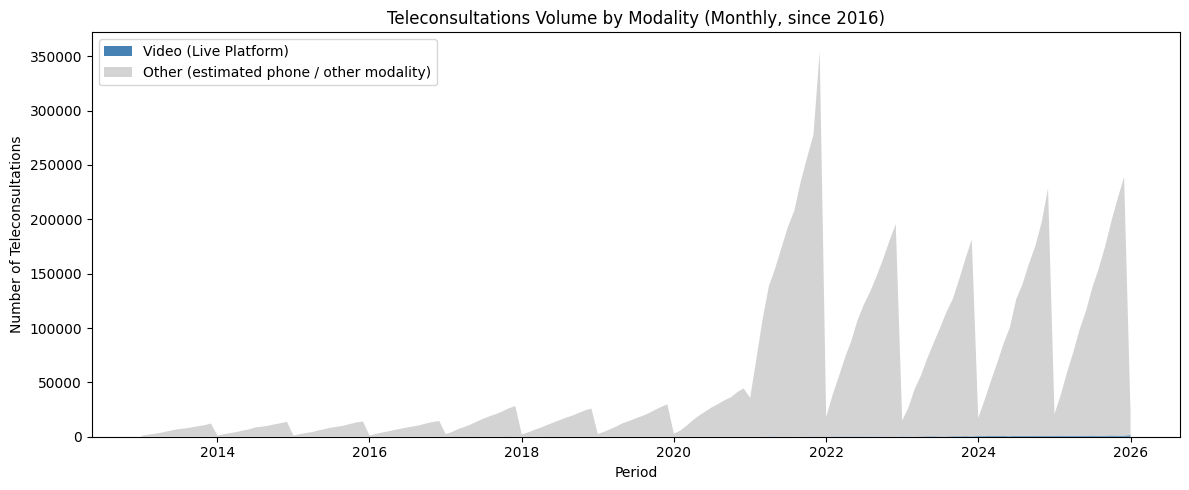

In [62]:
plt.figure(figsize=(12, 5))
plt.stackplot(
    modality["periodo_dt"],
    modality["total_live"],
    modality["estimated_other"],
    labels=["Video (Live Platform)", "Other (estimated phone / other modality)"],
    colors=["steelblue", "lightgray"]
)
plt.title("Teleconsultations Volume by Modality (Monthly, since 2016)")
plt.xlabel("Period")
plt.ylabel("Number of Teleconsultations")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

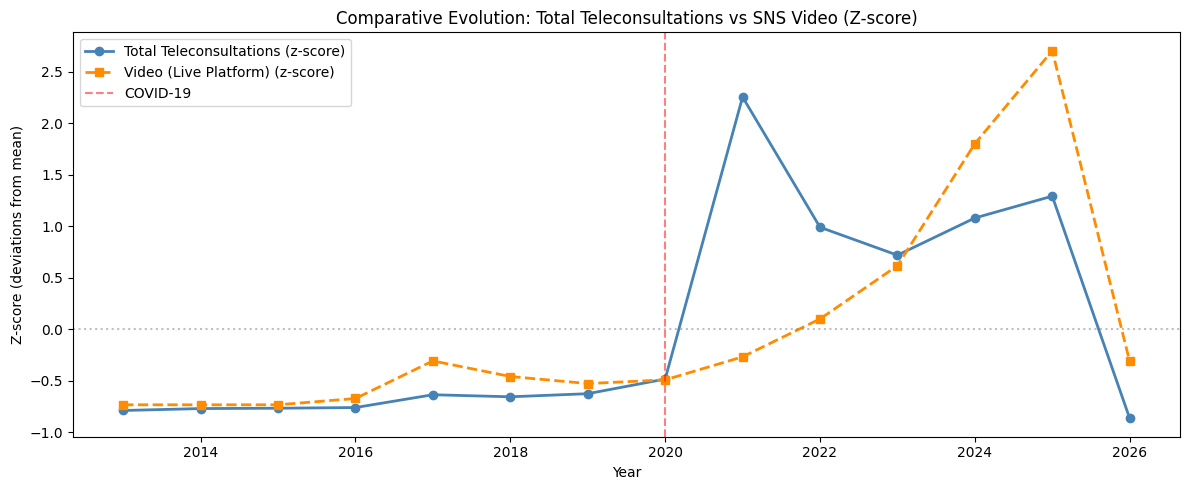

In [63]:
from scipy.stats import zscore

# Aggregate by year
df_anual = modality.resample("YE", on="periodo_dt").sum()

# Normalize both variables (z-score)
df_anual["total_z"] = zscore(df_anual["total_teleconsultas"])
df_anual["video_z"] = zscore(df_anual["total_live"])

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df_anual.index.year, df_anual["total_z"],
        "o-", color="steelblue", linewidth=2, label="Total Teleconsultations (z-score)")
ax.plot(df_anual.index.year, df_anual["video_z"],
        "s--", color="darkorange", linewidth=2, label="Video (Live Platform) (z-score)")

ax.axhline(0, color="grey", linestyle=":", alpha=0.5)
ax.axvline(2020, color="red", linestyle="--", alpha=0.5, label="COVID-19")
ax.set_ylabel("Z-score (deviations from mean)")
ax.set_xlabel("Year")
ax.set_title("Comparative Evolution: Total Teleconsultations vs SNS Video (Z-score)")
ax.legend()
plt.tight_layout()
plt.show()

## 10. Monthly Heatmap by Region

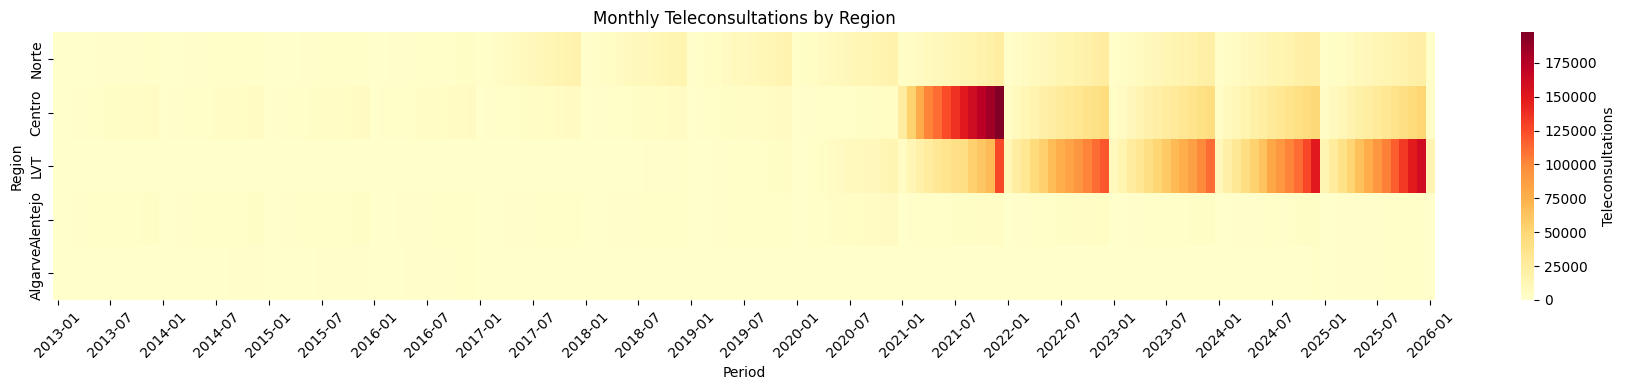

In [64]:
heat_data = tele2.groupby(["regiao", "periodo_dt"], as_index=False)["total"].sum()
heat_pivot = heat_data.pivot(index="regiao", columns="periodo_dt", values="total")
heat_pivot = heat_pivot.reindex(REGIOES)

plt.figure(figsize=(18, 4))
sns.heatmap(heat_pivot, cmap="YlOrRd", cbar_kws={"label": "Teleconsultations"})
plt.title("Monthly Teleconsultations by Region")
plt.xlabel("Period")
plt.ylabel("Region")

xticks = range(0, len(heat_pivot.columns), 6)
plt.xticks(
    [x + 0.5 for x in xticks],
    [heat_pivot.columns[x].strftime("%Y-%m") for x in xticks],
    rotation=45
)
plt.tight_layout()
plt.show()

## 11. Time Series Decomposition (STL) by Region

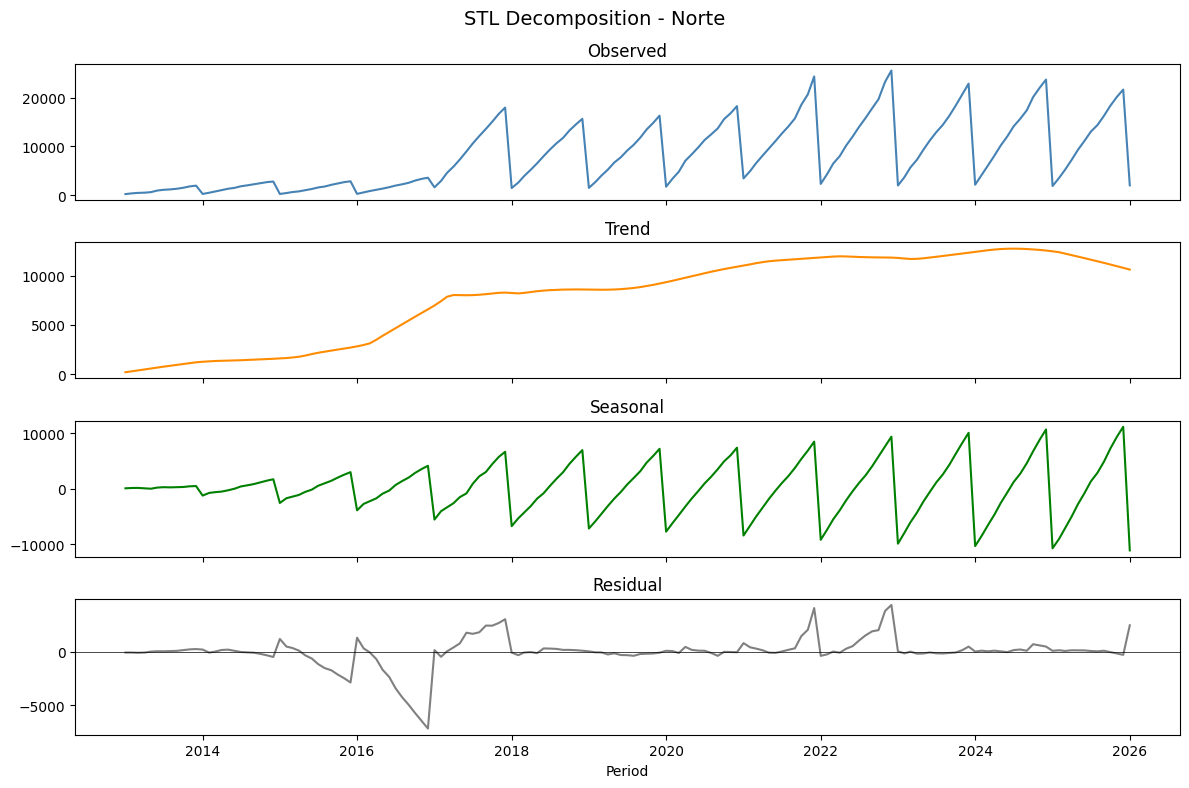

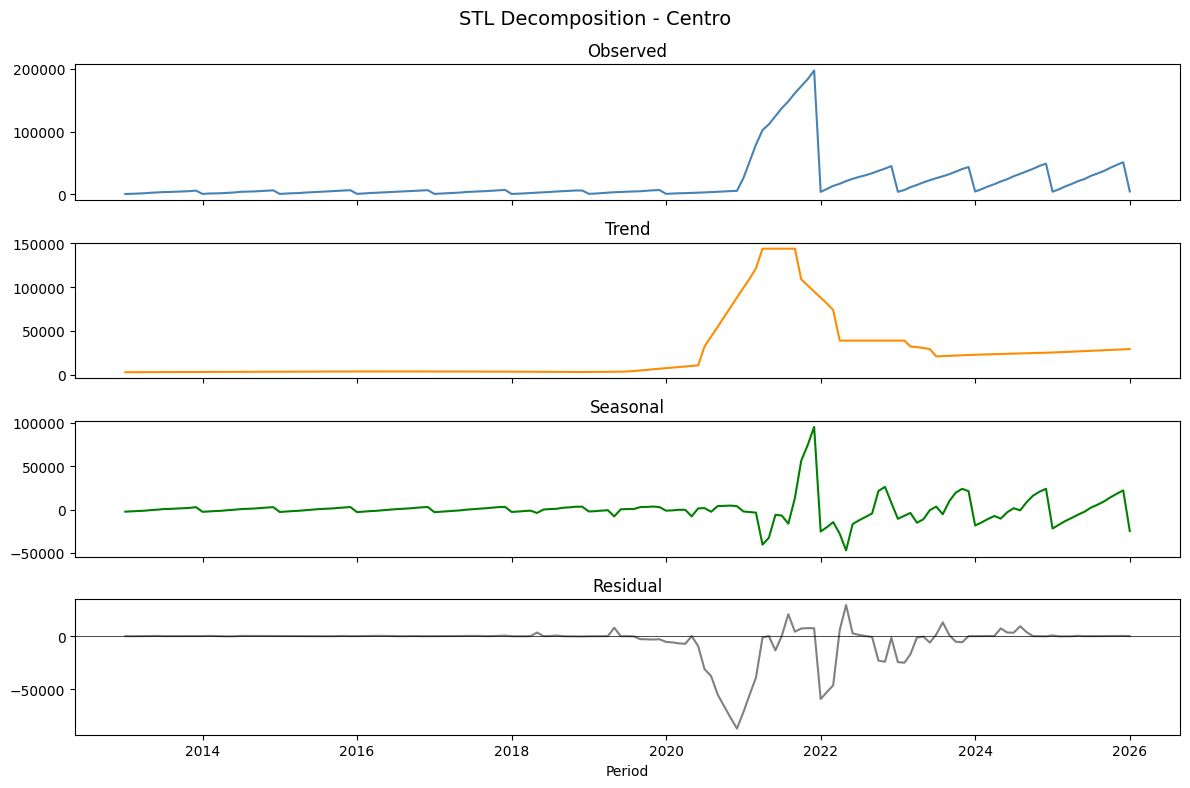

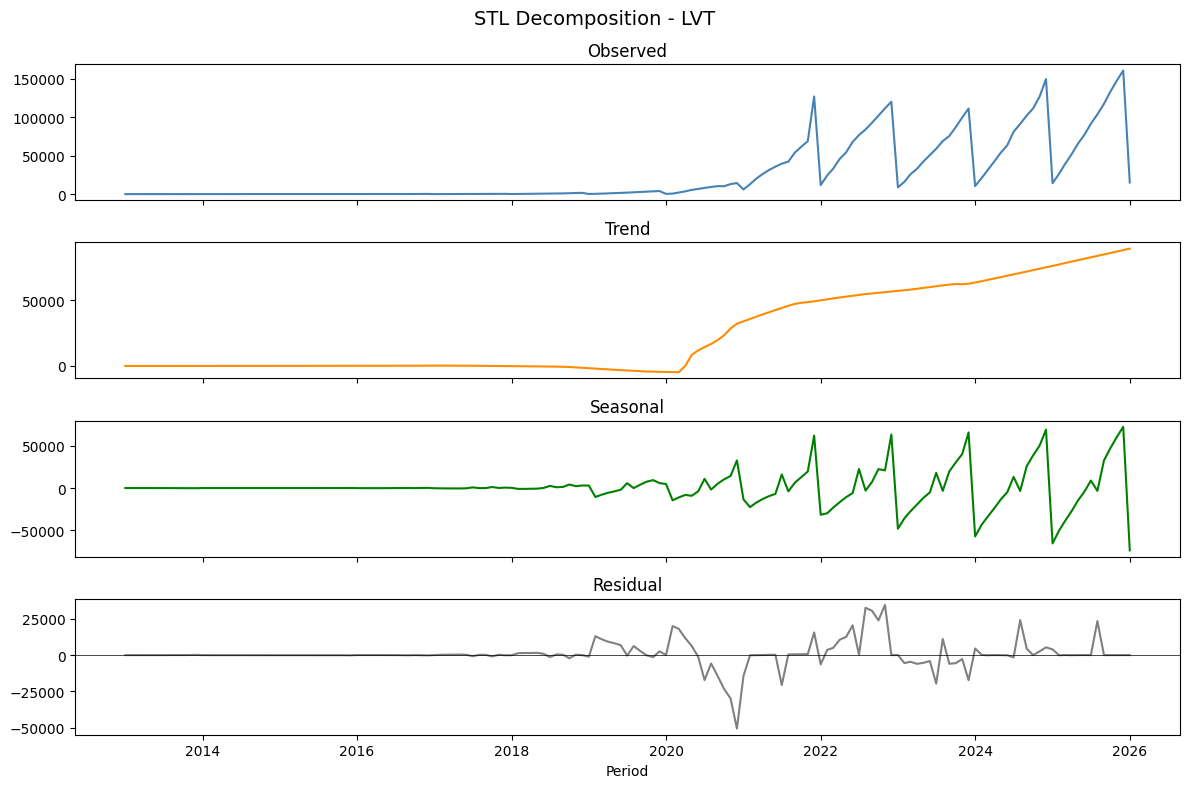

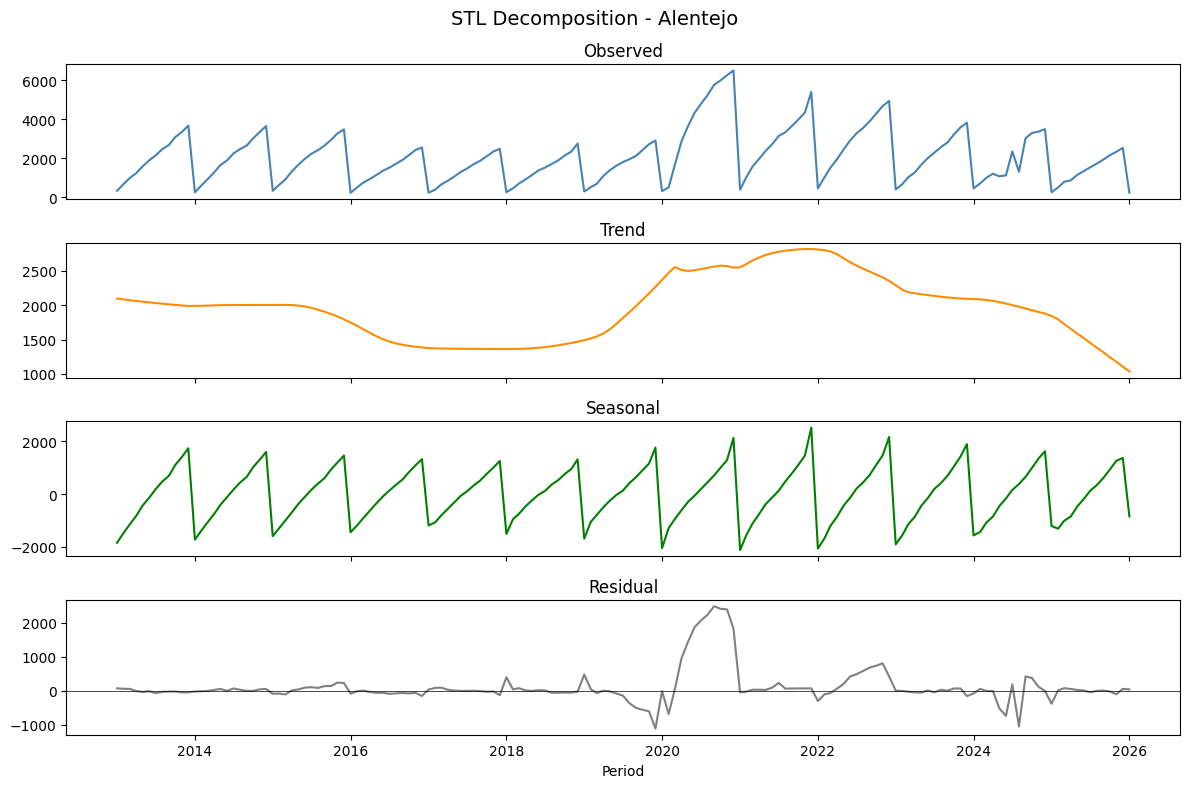

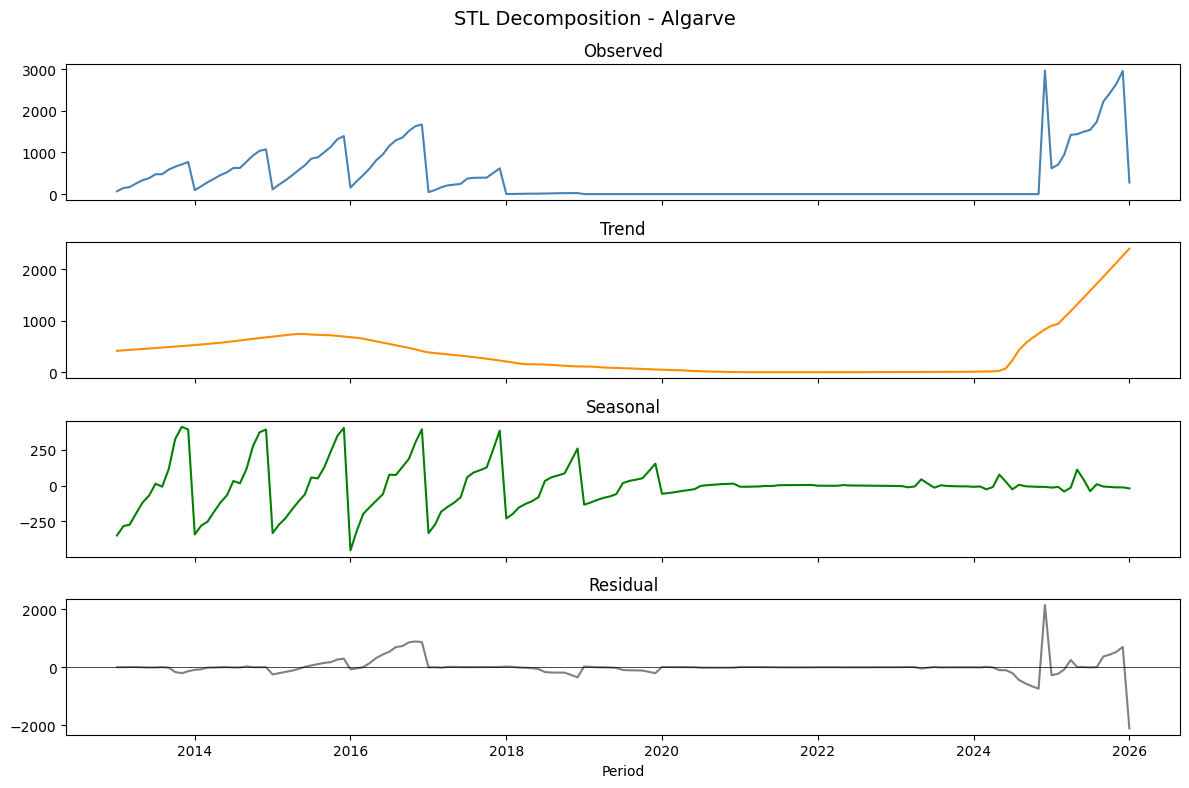

In [65]:
from statsmodels.tsa.seasonal import STL

for reg in REGIOES:
    series = heat_pivot.loc[reg].dropna()
    series.index = pd.DatetimeIndex(series.index)
    series = series.asfreq("MS").interpolate()

    stl = STL(series, period=12, robust=True)
    result = stl.fit()

    fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
    axes[0].plot(series.index, result.observed, color="steelblue")
    axes[0].set_title("Observed")
    axes[1].plot(series.index, result.trend, color="darkorange")
    axes[1].set_title("Trend")
    axes[2].plot(series.index, result.seasonal, color="green")
    axes[2].set_title("Seasonal")
    axes[3].plot(series.index, result.resid, color="gray")
    axes[3].axhline(0, color="black", linewidth=0.5)
    axes[3].set_title("Residual")
    axes[3].set_xlabel("Period")

    fig.suptitle(f"STL Decomposition - {reg}", fontsize=14)
    plt.tight_layout()
    plt.show()

## 12. Prophet Forecast by Region

In [66]:
!pip install prophet -q

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


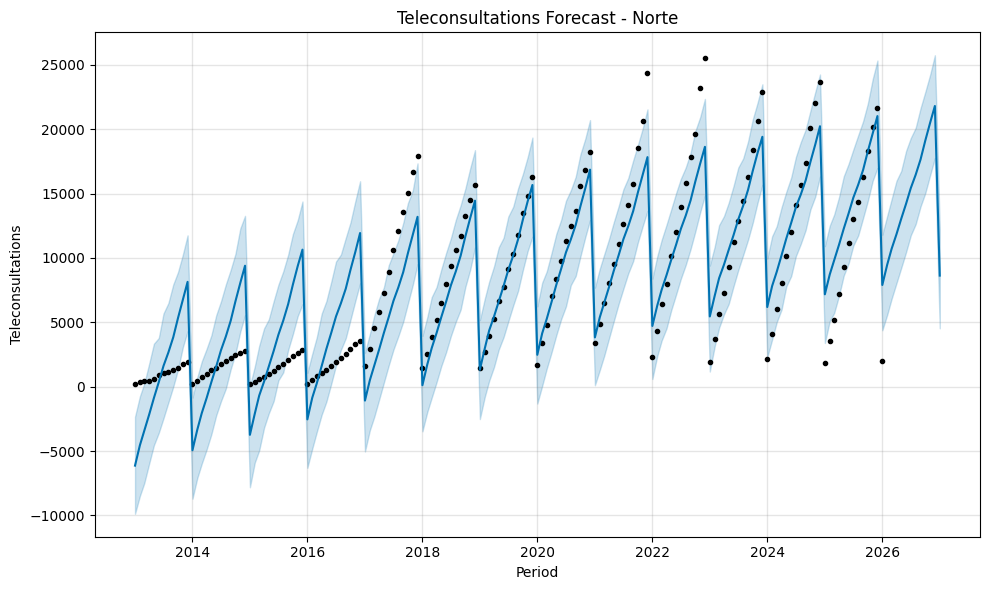

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


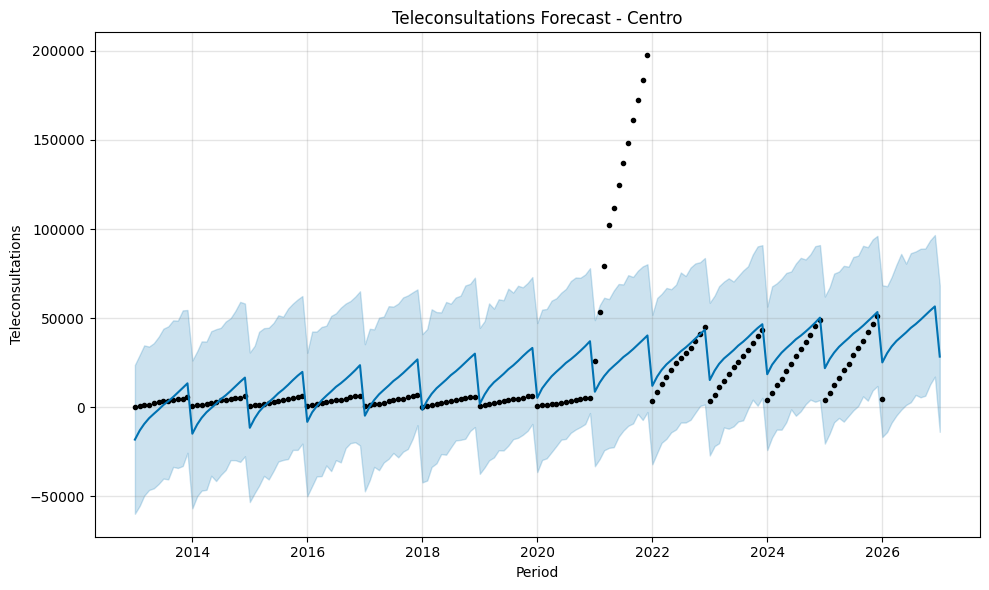

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


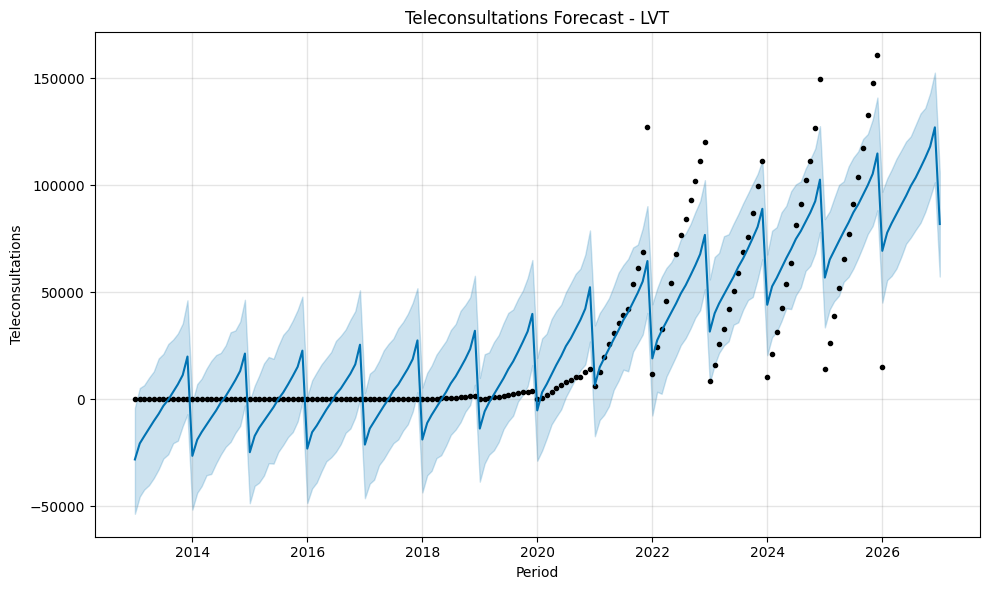

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


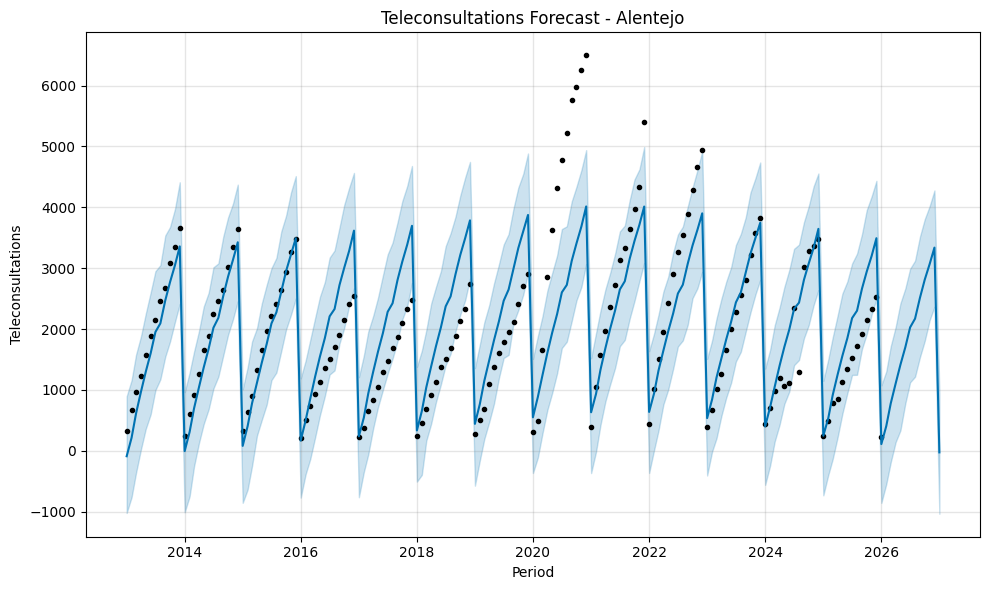

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


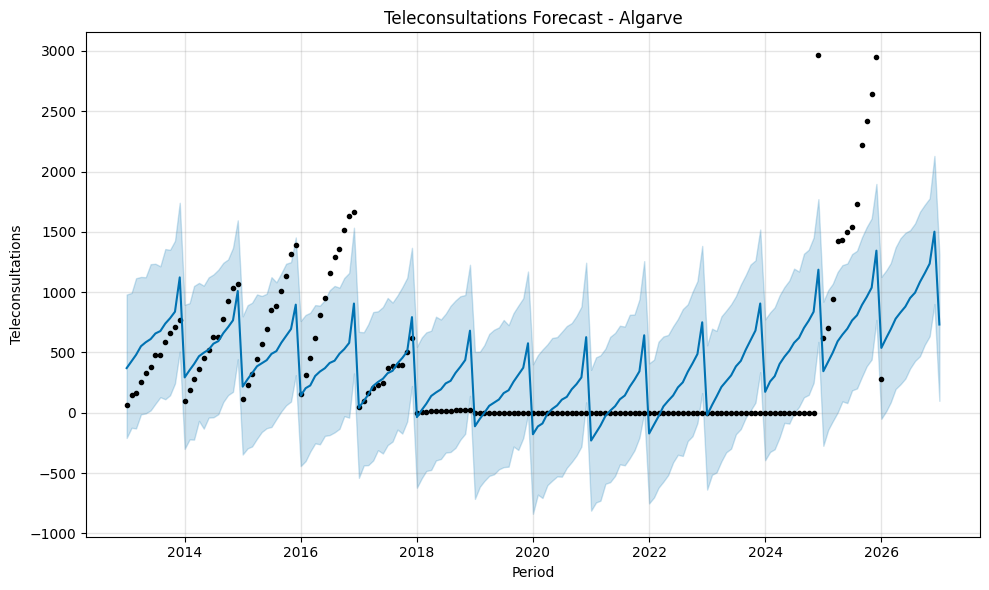

In [67]:
from prophet import Prophet
import matplotlib.pyplot as plt

forecasts = {}

for reg in REGIOES:
    series = heat_pivot.loc[reg].dropna()
    series.index = pd.DatetimeIndex(series.index)
    series = series.asfreq("MS").interpolate()

    df_prophet = pd.DataFrame({
        "ds": series.index,
        "y": series.values
    })

    model = Prophet(yearly_seasonality=True, seasonality_mode="additive")
    model.fit(df_prophet)

    future = model.make_future_dataframe(periods=12, freq="MS")
    forecast = model.predict(future)
    forecasts[reg] = forecast

    fig = model.plot(forecast)
    plt.title(f"Teleconsultations Forecast - {reg}")
    plt.xlabel("Period")
    plt.ylabel("Teleconsultations")
    plt.tight_layout()
    plt.show()


In [68]:
for reg in REGIOES:
    model_input = forecasts[reg]
    print(f"--- {reg}: next 12 months forecast ---")
    print(model_input[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(12).round(1).to_string(index=False))
    print()


--- Norte: next 12 months forecast ---
        ds    yhat  yhat_lower  yhat_upper
2026-02-01  9476.0      5583.8     13266.2
2026-03-01 10707.5      6819.4     14566.5
2026-04-01 11844.7      8042.1     15989.9
2026-05-01 13040.1      9220.4     16758.8
2026-06-01 14215.0     10456.0     18315.0
2026-07-01 15432.3     11760.8     19324.5
2026-08-01 16467.6     12632.3     20115.0
2026-09-01 17655.9     14001.9     21640.3
2026-10-01 19118.0     15036.4     22894.2
2026-11-01 20514.6     16441.9     24240.5
2026-12-01 21808.0     17767.7     25749.9
2027-01-01  8631.1      4535.6     12239.6

--- Centro: next 12 months forecast ---
        ds    yhat  yhat_lower  yhat_upper
2026-02-01 30378.7    -13876.8     67898.0
2026-03-01 34057.4     -8700.4     73019.6
2026-04-01 37193.3     -4618.9     79996.7
2026-05-01 39544.4     -1444.0     86052.1
2026-06-01 41967.2      1287.2     80597.5
2026-07-01 44532.7      2795.6     86445.2
2026-08-01 46659.7      6908.2     87423.6
2026-09-01 49099.

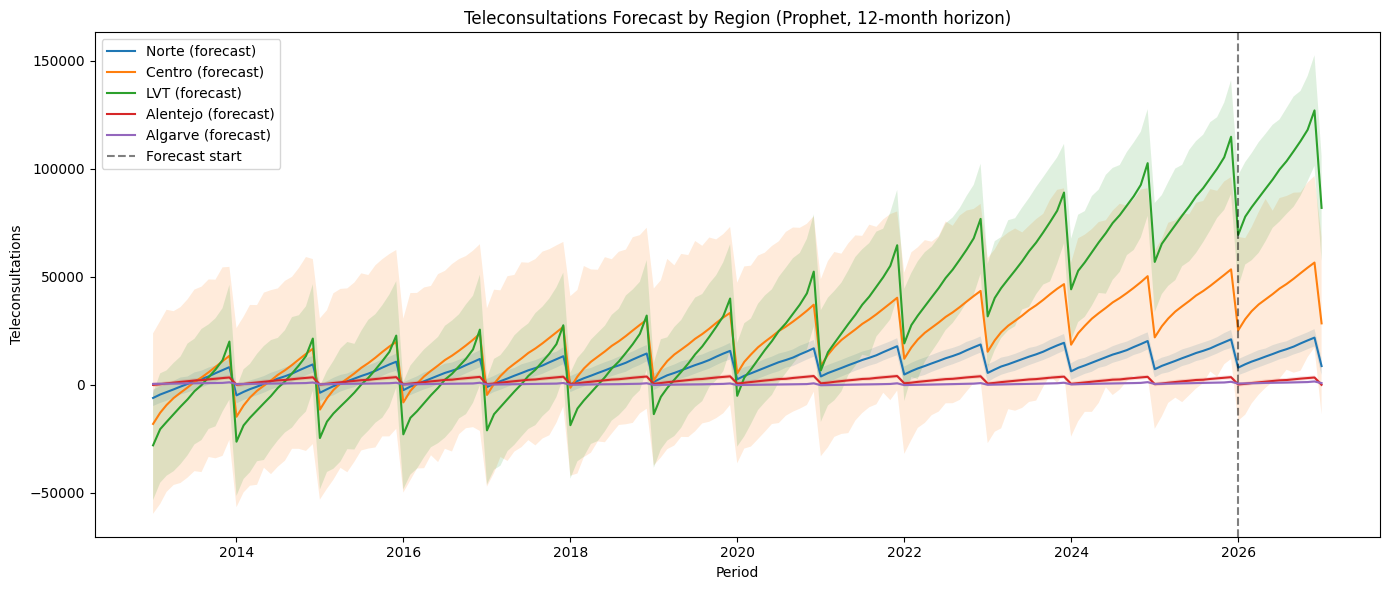

In [69]:
plt.figure(figsize=(14, 6))

for reg in REGIOES:
    fc = forecasts[reg]
    plt.plot(fc["ds"], fc["yhat"], label=f"{reg} (forecast)")
    plt.fill_between(fc["ds"], fc["yhat_lower"], fc["yhat_upper"], alpha=0.15)

plt.axvline(heat_pivot.columns.max(), color="black", linestyle="--", alpha=0.5, label="Forecast start")
plt.title("Teleconsultations Forecast by Region (Prophet, 12-month horizon)")
plt.xlabel("Period")
plt.ylabel("Teleconsultations")
plt.legend()
plt.tight_layout()
plt.show()

## 13. Teleconsultation Rate (vs Total Medical Consultations)

In [70]:
consultas_totais = pd.read_csv(
    folder + "/01_sica_evolucao-mensal-das-consultas-medicas-hospitalares.csv",
    sep=";",
    encoding="utf-8-sig"
)

consultas_totais.columns = [
    "periodo",
    "periodo_format2",
    "regiao",
    "instituicao",
    "geo",
    "total_consultas",
    "primeiras_consultas",
    "subsequentes_consultas"
]

consultas_totais["regiao"] = consultas_totais["regiao"].str.replace("Região de Saúde ", "").str.replace("do ", "")
consultas_totais = consultas_totais[consultas_totais["regiao"].isin(REGIOES)]

consultas_totais.head()

,periodo,periodo_format2,regiao,instituicao,geo,total_consultas,primeiras_consultas,subsequentes_consultas
0,2024-01,2024/01/01,Centro,"Unidade Local de Saúde Castelo Branco, EPE","39.822737, -7.499876",7812,2763,5049
1,2024-01,2024/01/01,Centro,"Unidade Local de Saúde da Cova da Beira, EPE","40.2776794433594, -7.0",14163,4149,10014
2,2024-01,2024/01/01,Centro,"Unidade Local de Saúde da Guarda, EPE","40.5309943471486, -7.0",8805,2345,6460
3,2024-01,2024/01/01,Norte,Unidade Local de Saúde da Póvoa de Varzim/Vila...,"41.383183, -8.758784",9932,3555,6377
4,2024-01,2024/01/01,Norte,"Unidade Local de Saúde de Barcelos/Esposende, EPE","41.533438, -8.616604",7440,2336,5104


In [71]:
# Total de consultas médicas (todas) por região e mês
consultas_mensal = consultas_totais.groupby(["regiao", "periodo"], as_index=False)["total_consultas"].sum()

# Total de teleconsultas por região e mês (a partir de tele2)
tele_mensal = tele2.groupby(["regiao", "periodo"], as_index=False)["total"].sum()
tele_mensal = tele_mensal.rename(columns={"total": "total_teleconsultas"})

taxa = consultas_mensal.merge(tele_mensal, on=["regiao", "periodo"], how="inner")
taxa["taxa_teleconsultas"] = (taxa["total_teleconsultas"] / taxa["total_consultas"]) * 100
taxa["periodo_dt"] = pd.to_datetime(taxa["periodo"], format="%Y-%m")

taxa.tail()

,regiao,periodo,total_consultas,total_teleconsultas,taxa_teleconsultas,periodo_dt
780,Norte,2025-09,4444693,16271.0,0.366077,2025-09-01
781,Norte,2025-10,5017097,18324.0,0.365231,2025-10-01
782,Norte,2025-11,5540904,20151.0,0.363677,2025-11-01
783,Norte,2025-12,5953276,21656.0,0.363766,2025-12-01
784,Norte,2026-01,537944,1986.0,0.369183,2026-01-01


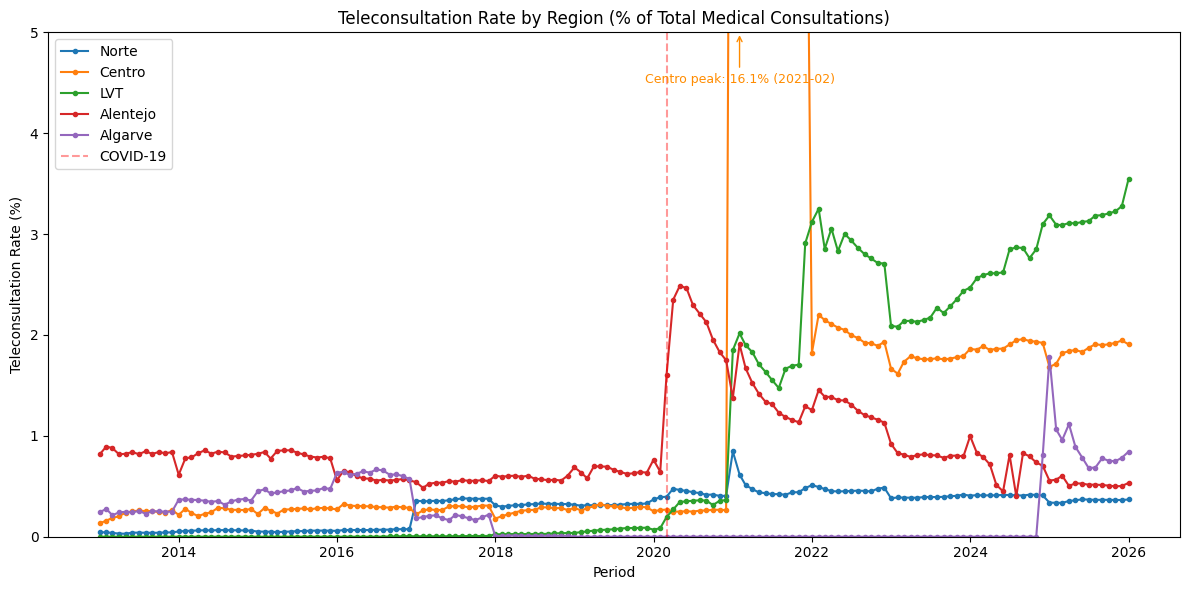

In [72]:
fig, ax = plt.subplots(figsize=(12, 6))

for reg in REGIOES:
    d = taxa[taxa["regiao"] == reg].sort_values("periodo_dt")
    ax.plot(d["periodo_dt"], d["taxa_teleconsultas"], marker="o", markersize=3, label=reg)

ax.axvline(pd.Timestamp("2020-03-01"), color="red", linestyle="--", alpha=0.4, label="COVID-19")
ax.set_ylim(0, 5)
ax.set_title("Teleconsultation Rate by Region (% of Total Medical Consultations)")
ax.set_xlabel("Period")
ax.set_ylabel("Teleconsultation Rate (%)")
ax.legend(loc="upper left")

# Annotate the Centro outlier (2021), which goes off the chart (~16%)
centro_outlier = taxa[(taxa["regiao"] == "Centro") & (taxa["taxa_teleconsultas"] > 5)]
if not centro_outlier.empty:
    peak = centro_outlier.loc[centro_outlier["taxa_teleconsultas"].idxmax()]
    ax.annotate(
        f"Centro peak: {peak['taxa_teleconsultas']:.1f}% ({peak['periodo']})",
        xy=(peak["periodo_dt"], 5), xytext=(peak["periodo_dt"], 4.5),
        ha="center", fontsize=9, color="darkorange",
        arrowprops=dict(arrowstyle="->", color="darkorange")
    )

plt.tight_layout()
plt.show()

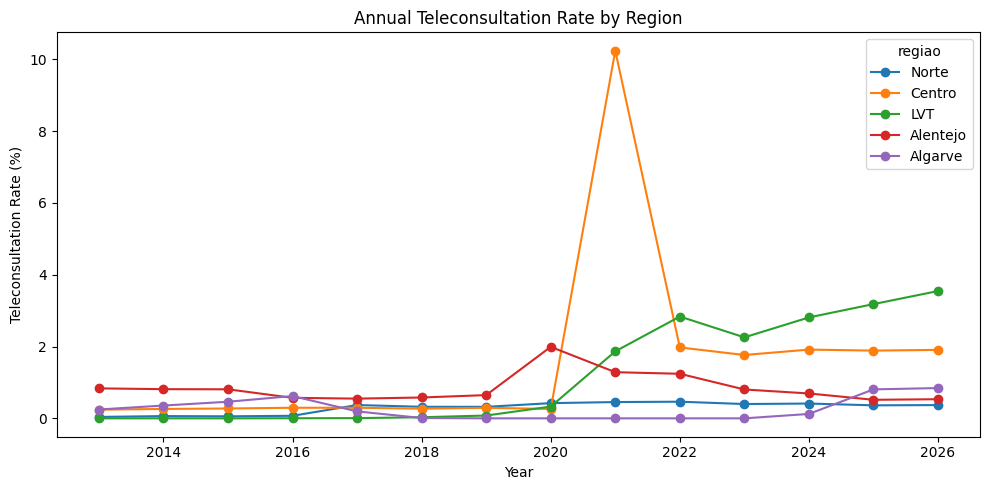

regiao  Norte  Centro   LVT  Alentejo  Algarve
ano                                           
2013     0.04    0.24  0.00      0.83     0.25
2014     0.06    0.26  0.00      0.81     0.36
2015     0.06    0.27  0.00      0.81     0.46
2016     0.07    0.29  0.00      0.57     0.62
2017     0.37    0.29  0.01      0.55     0.19
2018     0.32    0.27  0.03      0.58     0.01
2019     0.32    0.29  0.08      0.65     0.00
2020     0.42    0.26  0.33      1.99     0.00
2021     0.45   10.24  1.87      1.29     0.00
2022     0.46    1.98  2.84      1.24     0.00
2023     0.40    1.76  2.26      0.80     0.00
2024     0.41    1.92  2.81      0.69     0.12
2025     0.36    1.89  3.18      0.52     0.81
2026     0.37    1.91  3.55      0.53     0.84


In [73]:
# Taxa anual de teleconsultas por região
taxa["ano"] = taxa["periodo_dt"].dt.year

taxa_anual = taxa.groupby(["regiao", "ano"], as_index=False)[["total_consultas", "total_teleconsultas"]].sum()
taxa_anual["taxa_teleconsultas"] = (taxa_anual["total_teleconsultas"] / taxa_anual["total_consultas"]) * 100

pivot_anual = taxa_anual.pivot(index="ano", columns="regiao", values="taxa_teleconsultas")
pivot_anual = pivot_anual[REGIOES]

pivot_anual.plot(figsize=(10, 5), marker="o")
plt.title("Annual Teleconsultation Rate by Region")
plt.xlabel("Year")
plt.ylabel("Teleconsultation Rate (%)")
plt.tight_layout()
plt.show()

print(pivot_anual.round(2))